<a href="https://colab.research.google.com/github/Daniela1796/Caso-practico-ciclas/blob/main/ML_y_ciclo_de_vida_de_un_modelo_de_clasificaci%C3%B3n_de_notas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de clasificación de rendimiento de estudiantes en clases de matemáticas

- Realizado por: Daniela Segura
- código estudiantil: 1034063



---



## Importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)




---



## Comprensión y preparación de datos

### Carga del dataset



In [ ]:
df = pd.read_csv('/content/student-mat.csv', delimiter=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip().str.lower()

df.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,gp,f,15,u,le3,t,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


In [ ]:
print("Filas,columnas")
df.shape

Filas,columnas


(395, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


El dataset no tiene información faltante,pero tiene una gran variedad de tipos de datos, por lo que es importante entender qué significan cada uno de estos tipos, mediante un análisis más descriptivos utilizando ```describe()```

### Variables numéricas

In [ ]:
print("\033[1mTabla 1. Análisis de variables numéricas\033[0m"+ "\n")

df.describe()

Tabla 1. Análisis de variables numéricas



,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


En la **Tabla 1** podemos ver distintos propósitos para cada una de las columnas del dataset


1. Variables categóricas ordinales como Medu, Fedu, traveltime y studytime, que representan escalas (por ejemplo, nivel educativo o tiempo de traslado) y no cantidades continuas propiamente dichas.

2. Existen variables numéricas continuas como edad, ausencias (Abscences) y las notas G1, G2, G3 que se deberán escalar para el modelo.

3. Las notas G1, G2 y G3 representran las notas en el período 1, 2 y la nota final respectivamente. Como el objetivo es predecir cómo los estudiantes obtienen sus notas finales en matemáticas a través de los diferentes contextos que vive cada estudiante, sería conveniente no introducir al modelo estos datos porque naturalmente G3 depende de G1 Y G2.



### Variables categóricas

In [ ]:
print("\033[1mTabla 2. Análisis de variables categóricas\033[0m"+ "\n")
df.describe(include='object')

Tabla 2. Análisis de variables categóricas



,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,gp,f,u,gt3,t,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


En la **Tabla 2** podemos observar dos tipos de clasificaciones:

1. Columnas categóricas con 2 variables únicas [ ```unique```] serán facilmente transformadas a variables binarias.

2. Las columnas con más de 2 variables únicas implican que contienen un rango de información más extenso que debe comprenderse para entender los resultados del modelo.

### Variable objetivo

Antes de preparar las variables predictorias y objetivo, es importante entender la variable objetivo  y si es importante considerar las primeras notas (G1 y G2) fuera del modelo

Se estudia primero la correlación de las variables

          G1        G2        G3
G1  1.000000  0.852118  0.801468
G2  0.852118  1.000000  0.904868
G3  0.801468  0.904868  1.000000


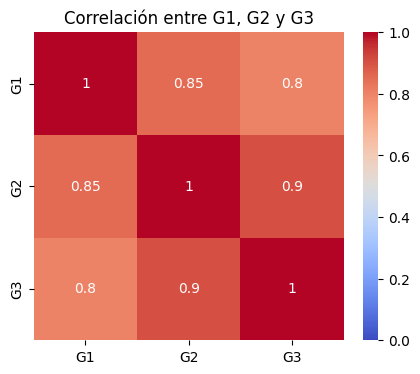

In [ ]:
# Correlación entre G1, G2 y G3
corr_notas = df[['G1', 'G2', 'G3']].corr()
print(corr_notas)

plt.figure(figsize=(5,4))
sns.heatmap(corr_notas, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlación entre G1, G2 y G3')
plt.show()

En interpretación del gráfico que se realiza con la guía de Ortega (2023),

1. La correlación entre G1 y G3 (0.80) es la más baja de las tres porque G1 es la nota más distante en el tiempo respecto a G3. Por lo que

3. La correlación entre G2 y G3 es mucho más positiva (0.9) esto implica que G2 permite conocer de manera más certera la calificación por su cercanía en tiempo, siendo entonces G2 una variable predictiria fuerte.

Utilizando Gemini para interpretar la matriz de correlación nos dice:

>**Prompt**: Qué interpretación se le da a la correlación entre las notas G1, G2 y G3?

En cuanto a la interpretación de los valores:

- Diagonal principal (1.00): La correlación de una variable consigo misma es siempre 1, lo cual es de esperar.

- Fuertes correlaciones positivas: Los valores fuera de la diagonal (0.80, 0.85, 0.90) indican una correlación positiva muy fuerte entre las notas. Esto significa que los estudiantes que tienen buenas calificaciones en el primer período (G1) tienden a tener buenas calificaciones en el segundo período (G2) y en la nota final (G3), y viceversa.

- G2 y G3 (0.90): La correlación más alta es entre G2 y G3 (0.90), lo que sugiere que la nota del segundo período es un predictor extremadamente fuerte de la nota final. Esto refuerza la idea mencionada anteriormente de que G1 y G2 podrían ser eliminadas si el objetivo es predecir G3 basándose en factores contextuales y no en el rendimiento previo en el mismo curso, para evitar un posible data leakage o que el modelo se enfoque demasiado en estas variables altamente correlacionadas en lugar de otros atributos del estudiante.

>En conclusión, si se conservan G1 y G2 en los modelos, estas variables se convertirían en variables predictorias determinantes para predecir el rendimeinto final del estudiante. Como el contexto del dataset también trae factores personales que se deben tener en cuenta en el modelo, se excluyen G1 y G2 para mejorar el desempeño de los modelos.



---



Otros factores de comprensión de la variable objetivo G3, utilizando ```describe()```podemos ver los valores mínimos y máximos.

In [ ]:
print('\033[1mTabla 3. Descripción estadística de G3\033[0m')
df['G3'].describe()

Tabla 3. Descripción estadística de G3


,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


Como observamos en la **Tabla 3** conocemos que el rango de calificación es de 0 (**min**) a 20 (**max**).

Otros factores estadísticos:

- Promedio: nos muestra que de los 395 estudiantes, se obtiene un promedio de nota del 10.41.

- Variación estándar: este nos muestra la dispersión de las notas alrededor del promedio general de los estudiantes reportados.

- Percentiles 25, 50, 75: dentro del 25% de los estudiantes obtuvo 8.0 o menos nota, el 50% que nos determina la mediana obtuvo una nota de 11 y el 75% obtuvo 14.0 o menos.


**Por otro lado**, es necesario observar más de cerca la distribución de las notas reportadas.

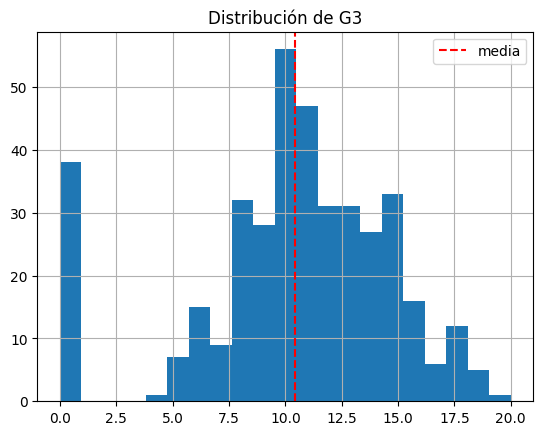

In [ ]:
df['G3'].value_counts().sort_index()
df['G3'].hist(bins=21)
plt.axvline(df['G3'].mean(), color='red', linestyle='--', label='media')
plt.title('Distribución de G3')
plt.legend()
plt.show()

Podemos observar que las notas en 0.0 es uno de los reportes más frecuentes en el dataset.Esta información es importante ya que muestra que esa población de estudiantes debe considerarse dentro del entrenamiento y prueba.

Algo que debe considerarse siempre, es el contexto del dataset, no solo vemos factores escolares sino personales del estudiante, por lo que, es necesario interpretar los resultados con todo el panorama contextualizado.



---



### Preparación de X e Y

- Creamos una copia del dataframe original con el que se hará la preparación de los datos para conservar los datos originales en caso de que se necesite hacer alguna comparación.

In [ ]:
df_copy = df.copy()
df.head(3)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,gp,f,15,u,le3,t,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


In [ ]:
print("Tamaño del dataframe copia: ",df.shape)

Tamaño del dataframe copia:  (395, 33)


### Transformación y escalado de las variables

**Variables categóricas binarias**

Columnas YES, NO: schoolsup, famsup, paid, activities, nursery, higher, internet, romantic.

Columnas sex - F, M

Columna  school - GP (Gabriel Pereira), MS (Mousinho da Silveira)

Columna address:  U, R (rural)

Columna famsize: LE3 (less that 3), GT3

Columna Pstatus: T: together, A (apart)



In [ ]:
df_copy['schoolsup'] = df_copy['schoolsup'].map({'yes': 1, 'no': 0})
df_copy['famsup'] = df_copy['famsup'].map({'yes': 1, 'no': 0})
df_copy['paid'] = df_copy['paid'].map({'yes': 1, 'no': 0})
df_copy['activities'] = df_copy['activities'].map({'yes': 1, 'no': 0})
df_copy['nursery'] = df_copy['nursery'].map({'yes': 1, 'no': 0})
df_copy['higher'] = df_copy['higher'].map({'yes': 1, 'no': 0})
df_copy['internet'] = df_copy['internet'].map({'yes': 1, 'no': 0})
df_copy['romantic'] = df_copy['romantic'].map({'yes': 1, 'no': 0})

df_copy.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,gp,f,18,u,gt3,a,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,gp,f,17,u,gt3,t,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,gp,f,15,u,le3,t,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


Procederemos a mapear las otras variables binarias listadas: `sex`, `school`, `address`, `famsize`, `Pstatus`.

In [ ]:
df_copy['sex'] = df_copy['sex'].map({'f': 1, 'm': 0})
df_copy['school'] = df_copy['school'].map({'gp': 1, 'ms': 0})
df_copy['address'] = df_copy['address'].map({'u': 1, 'r': 0})
df_copy['famsize'] = df_copy['famsize'].map({'gt3': 1, 'le3': 0})
df_copy['Pstatus'] = df_copy['Pstatus'].map({'t': 1, 'a': 0})

df_copy.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,1,1,18,1,1,0,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,1,1,17,1,1,1,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,1,1,15,1,0,1,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


Verificación de los mapeos de las variables anteriores

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    int64 
 1   sex         395 non-null    int64 
 2   age         395 non-null    int64 
 3   address     395 non-null    int64 
 4   famsize     395 non-null    int64 
 5   Pstatus     395 non-null    int64 
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    int64 
 16  famsup      395 non-null    int64 
 17  paid        395 non-null    int64 
 18  activities  395 non-null    int64 
 19  nursery     395 non-null    int64 
 20  higher    

**Transformar <'y'>  en variable binaria**

In [ ]:
# Binarizar la nota final G3 (Aprobado >= 10, Reprobado < 10)
df_copy['G3_bin'] = np.where(df_copy['G3'] >= 10, 1, 0)

# Verificar la distribución de la nueva variable binaria
print(df_copy['G3_bin'].value_counts())
display(df_copy[['G3', 'G3_bin']].head())

G3_bin
1    265
0    130
Name: count, dtype: int64


,G3,G3_bin
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


- Definimos las variables ```feature``` y ```target```

In [ ]:
X = df_copy.drop(columns=['G1', 'G2', 'G3', 'G3_bin'])
y = df_copy['G3_bin']

print("X: ", X.shape)
print("y: ", y.shape )

X:  (395, 30)
y:  (395,)


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    int64 
 1   sex         395 non-null    int64 
 2   age         395 non-null    int64 
 3   address     395 non-null    int64 
 4   famsize     395 non-null    int64 
 5   Pstatus     395 non-null    int64 
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    int64 
 16  famsup      395 non-null    int64 
 17  paid        395 non-null    int64 
 18  activities  395 non-null    int64 
 19  nursery     395 non-null    int64 
 20  higher    

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 395 entries, 0 to 394
Series name: G3_bin
Non-Null Count  Dtype
--------------  -----
395 non-null    int64
dtypes: int64(1)
memory usage: 3.2 KB


In [ ]:
y.head(3)

,G3_bin
0,0
1,0
2,1


**Transformar variables categóricas con rangos más amplios OneHot Encoding**

Columnas categóricas: mjob, Fjob, reason, guardian.

**Escalar variables numéricas**

Columnas numéricas: age,Medu, Fedu, traveltime, studytime, failures,  famrel, freetime, goout, Dalc, Walc, health, absences.

In [ ]:
columnas_categoricas = X.select_dtypes(include=["object"]).columns
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns

print("Columnas categóricas:")
print(list(columnas_categoricas))
print("Columnas numéricas:")
print(list(columnas_numericas))

Columnas categóricas:
['Mjob', 'Fjob', 'reason', 'guardian']
Columnas numéricas:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
preprocesamiento = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

### Separación de datos en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (276, 30)
Prueba: (119, 30)


Se utiliza una proporción 70/30 dado el tamaño moderado del dataset (395 registros), lo que deja un conjunto de prueba suficientemente grande (119 estudiantes) para evaluar el modelo con confianza.

Con ```stratify``` fijado en 'y' se asegura una proporción adecuada para todas las notas en G3 en entrenamiento y prueba.

## Fase 2: Clasificación - Regresión logística y SVM

### Regresión logística

**Construcción del pipeline**

En la construcción del pipeline, introducimos las variables preprocesadas anteriormente y utilizando ```logisticRegression()```  con una iteración de 1000 [estándar para prácticas].

```.fit()``` permite aplicar a las transformaciones o las variables preprocesadas antes de entrenar el modelo.





In [ ]:
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", LogisticRegression(max_iter=1000))
])

# Ajustar modelo con la variable binaria
modelo_logistico.fit(X_train, y_train)
pred_log = modelo_logistico.predict(X_test)


### **Accuracy, precisión, recall y f1-score**

In [ ]:
print("Tabla 4. Reporte de clasificación regresión logística \n")
print(classification_report(y_test, pred_log, target_names=["Reprobado", "Aprobado"]))

Tabla 4. Reporte de clasificación regresión logística 

              precision    recall  f1-score   support

   Reprobado       0.47      0.36      0.41        39
    Aprobado       0.72      0.80      0.76        80

    accuracy                           0.66       119
   macro avg       0.59      0.58      0.58       119
weighted avg       0.64      0.66      0.64       119



Los datos que obtuvimos con el conjunto de prueba determinada que es 119 reportes:

- **Accuracy**: el modelo logra un 66% de éxito al clasificar los estudiantes en las dos categorías.

- **Precisión**: considerando las el conjunto de datos de prueba, la precisión nos muestra que el modelo predijo correctamente el 72% de estudiantes aprobados y 47% de reprobados.

- **Recall**: el modelo tuvo una identificación correcta del 80% de estudiantes frente a una cantidad de 80 que realmente aprobaron según el support y solo del 36% para reprobados frente a la cantidad de 36 estudiantes que aprobaron.

- **F1-score**:  esta característica nos resuyme la precisión y el recall, en este caso, nos muestra que, el modelo tiene un 76% de probabilidad de predecir que estudiantes aprueban y un 41% para los que reprueban.

Cómo tal, el modelo tiene un accuracy que puede ser adecuada, al analizar las optras variables vemos que el modelo predice más eficientemente a los aprobados que ene general persisten de manera más consistente que los aprobados, cómo se pudo ver en el análisis anterior.

>

Los datos que obtuvimos de la regresión logística son:

- **Accuracy**: El modelo logró clasificar correctamente al 66% de los estudiantes en el conjunto de prueba.

- **Precisión**:
  - **Reprobado**: De todas las predicciones de "Reprobado", solo el 47% fueron correctas. Esto significa que el modelo tiene una alta tasa de falsos positivos para esta clase (predice "Reprobado" cuando el estudiante realmente aprobó).
  - **Aprobado**: De todas las predicciones de "Aprobado", el 72% fueron correctas. La precisión es mucho mejor para la clase de "Aprobado".

- **Recall** (Sensibilidad):
  - **Reprobado**: El modelo identificó correctamente solo el 36% de todos los estudiantes que realmente reprobaron. Esto indica que el modelo tiene una alta tasa de falsos negativos para esta clase (no detecta a muchos de los estudiantes que realmente reprobaron).
  - **Aprobado**: El modelo identificó correctamente el 80% de todos los estudiantes que realmente aprobaron. El recall es bastante bueno para la clase de "Aprobado".

- **F1-score**: Es la media armónica de precisión y recall.
  - **Reprobado**: El F1-score es bajo (0.41), lo que refleja la baja precisión y recall para esta clase.
  - **Aprobado**: El F1-score es alto (0.76), lo que indica un buen equilibrio entre precisión y recall para esta clase.

- **Support**: Es el número real de instancias de cada clase en el conjunto de prueba (39 reprobados, 80 aprobados).

En resumen, el modelo de regresión logística tiene un rendimiento aceptable para predecir a los estudiantes que aprueban (alta precisión y recall), pero es menos efectivo para identificar a los que reprueban, con una cantidad considerable de falsos positivos y falsos negativos en esa categoría.

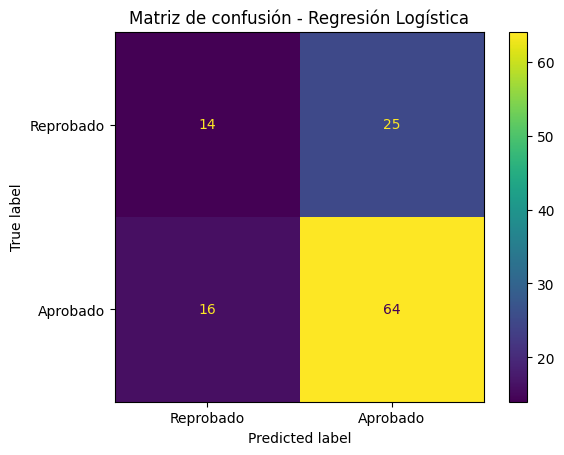

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_log,
    display_labels=["Reprobado", "Aprobado"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.show()


In [ ]:
resultados = pd.DataFrame({
    'real': y_test.values,
    'prediccion': pred_log
}, index=y_test.index)

falsos_positivos = resultados[(resultados['real'] == 0) & (resultados['prediccion'] == 1)]
falsos_negativos = resultados[(resultados['real'] == 1) & (resultados['prediccion'] == 0)]

print(f"Falsos Positivos: {len(falsos_positivos)}")
print(f"Falsos Negativos: {len(falsos_negativos)}")

Falsos Positivos: 25
Falsos Negativos: 16


La matriz de confusión nos muestra dos diagonales:

- La diagonal principal nos muestra los aciertos del modelo, como podemos ver, dónde le númeor de aprobados (64) reales con los predichos, y es más bajo para los casos aprobados (14). Esto se debe a que las notas de aprobación son mayoría en el dataset.


- La diagonal invertida muestra lo contrario, tenemos 25 casos de estudiantes reprobados pero que bajo el modelo aprueban, y 16 casos donde los estudiantes aprueban, lo cuál en una aplicación real podría traer consecuencias negativas.

Para entenderlo mejor, se muestran las tablas de los falsos negativos y positivos, lo cuales se analizaran con Gemini ya que hay múltiples factores estadísticos, especialmente para no escoger valores que puedan sesgar las razones de interpretación del modelo.

In [112]:
# Ver las características de los estudiantes mal clasificados
print("Tabla 5. Estadísticas de los estudiantes FP \n")
df_copy.loc[falsos_positivos.index].describe()

Tabla 5. Estadísticas de los estudiantes FP 



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_bin
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.0,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.00,25.000000,25.000000,25.000000,25.000000,25.0
mean,0.880000,0.640000,17.120000,0.840000,0.640000,0.840000,2.520000,2.2,1.360000,1.960000,...,2.920000,2.840000,1.560000,2.440000,3.24,7.120000,8.160000,7.240000,5.480000,0.0
std,0.331662,0.489898,0.881287,0.374166,0.489898,0.374166,1.004988,1.0,0.757188,0.789515,...,0.759386,0.943398,0.869866,1.293574,1.30,11.609335,1.518771,2.067204,3.652853,0.0
min,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00,0.000000,5.000000,0.000000,0.000000,0.0
25%,1.000000,0.000000,17.000000,1.000000,0.000000,1.000000,2.000000,1.0,1.000000,2.000000,...,3.000000,2.000000,1.000000,1.000000,2.00,0.000000,7.000000,6.000000,0.000000,0.0
50%,1.000000,1.000000,17.000000,1.000000,1.000000,1.000000,2.000000,2.0,1.000000,2.000000,...,3.000000,3.000000,1.000000,2.000000,3.00,4.000000,8.000000,8.000000,6.000000,0.0
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,3.000000,3.0,1.000000,2.000000,...,3.000000,3.000000,2.000000,3.000000,5.00,10.000000,9.000000,9.000000,8.000000,0.0
max,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000,4.000000,4.0,4.000000,4.000000,...,4.000000,5.000000,4.000000,5.000000,5.00,56.000000,11.000000,10.000000,9.000000,0.0


In [113]:
print("Tabla 5. Estadísticas de los estudiantes FN \n")
df_copy.loc[falsos_negativos.index].describe()

Tabla 5. Estadísticas de los estudiantes FN 



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_bin
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.0,16.000000,16.000000,16.000,16.0000,...,16.000000,16.000000,16.000000,16.00000,16.000000,16.000000,16.000000,16.000000,16.000000,16.0
mean,0.687500,0.687500,17.437500,0.687500,0.875000,1.0,2.250000,2.375000,1.375,2.3125,...,3.437500,3.125000,1.437500,2.06250,3.312500,7.625000,11.812500,11.375000,11.562500,1.0
std,0.478714,0.478714,1.314978,0.478714,0.341565,0.0,0.930949,1.147461,0.500,0.7932,...,1.314978,1.310216,1.030776,1.28938,1.078193,9.471888,2.786126,2.028957,1.631717,0.0
min,0.000000,0.000000,15.000000,0.000000,0.000000,1.0,1.000000,1.000000,1.000,1.0000,...,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,7.000000,8.000000,10.000000,1.0
25%,0.000000,0.000000,17.000000,0.000000,1.000000,1.0,2.000000,1.000000,1.000,2.0000,...,3.000000,2.000000,1.000000,1.00000,3.000000,3.500000,10.000000,10.000000,10.000000,1.0
50%,1.000000,1.000000,17.500000,1.000000,1.000000,1.0,2.000000,2.500000,1.000,2.0000,...,3.500000,3.000000,1.000000,1.50000,3.000000,4.000000,11.500000,11.500000,11.000000,1.0
75%,1.000000,1.000000,18.250000,1.000000,1.000000,1.0,3.000000,3.000000,2.000,3.0000,...,4.250000,4.000000,1.250000,3.00000,4.000000,8.500000,14.250000,13.000000,13.000000,1.0
max,1.000000,1.000000,19.000000,1.000000,1.000000,1.0,4.000000,4.000000,2.000,4.0000,...,5.000000,5.000000,5.000000,5.00000,5.000000,40.000000,16.000000,15.000000,15.000000,1.0


Al analizar y comparar los estadísticos descriptivos de los Falsos Positivos (estudiantes que reprobaron pero el modelo predijo que aprobarían, Celda E3bTkJQXc8fH) y los Falsos Negativos (estudiantes que aprobaron pero el modelo predijo que reprobarían, Celda 9IUztp8Cd8mY), podemos extraer conclusiones clave sobre qué factores están confundiendo a nuestro modelo de Regresión Logística:

1. Falsos Positivos (25 estudiantes)
Rendimiento histórico real (G1 y G2): Tienen un promedio de G1 = 8.16 y G2 = 7.24, con una nota final real promedio de G3 = 5.48 (todos reprobados, ya que el máximo de G3 en este grupo es 9.0).
Ausencias: Tienen un promedio alto de ausencias (7.12), llegando en casos extremos hasta 56 ausencias.
Factores de confusión: Estos estudiantes tienen perfiles contextuales bastante favorables que el modelo asocia fuertemente con el éxito:
Un 88% asiste al colegio GP (asociado con mejor rendimiento).
El 84% vive en zona urbana (address = 1).
El 64% tiene familias de tamaño grande (famsize = 1).
Tienen promedios de tiempo de estudio decentes (1.96) y un bajo número de fallas previas en comparación con otros estudiantes que reprueban.
Implicación: El modelo se deja engañar por sus buenas condiciones contextuales (viven en zona urbana, estudian en un colegio con mejor promedio, baja tasa de reprobación histórica general) e ignora que su rendimiento real en clase y sus ausencias acumuladas los llevaron a reprobar.
2. Falsos Negativos (16 estudiantes)
Rendimiento histórico real (G1 y G2): Tienen un promedio de G1 = 11.81 y G2 = 11.37, logrando aprobar de manera real con una media de G3 = 11.56.
Ausencias: Promedian 7.62 ausencias (un valor ligeramente elevado, con un máximo de 40).
Factores de confusión: Sus entornos son más desafiantes o menos comunes para un perfil de aprobación según el modelo:
Un 31.2% asiste al colegio MS (school = 0.68 promedio en el grupo, es decir, hay mayor presencia de MS que en los aprobados típicos).
Un 31.2% vive en áreas rurales (address = 0.68).
El nivel educativo de los padres es menor (Medu promedio de 2.25 y Fedu de 2.37, comparado con el promedio general).
Reportan un mayor tiempo libre (3.43 de freetime) y salidas con amigos (3.12 de goout).
Implicación: El modelo asume que estos estudiantes van a reprobar porque provienen de entornos socioeconómicos o familiares más vulnerables o porque dedican más tiempo al ocio. Sin embargo, su esfuerzo personal o aptitud (reflejados en sus notas previas G1 y G2, que fueron excluidas del modelo) les permitió superar esas barreras y aprobar.

Conclusión para el Modelo

Esto demuestra la limitación de entrenar un modelo predictivo excluyendo el historial académico reciente (G1 y G2). El contexto social es un indicador general, pero no determina por completo el desempeño individual. Para reducir estos errores en producción, se podría:

Incorporar de forma controlada una métrica de rendimiento reciente (como el promedio de notas del año anterior).
Darle un peso mayor o penalización en el entrenamiento a la variable de ausencias (absences) y fallas previas (failures), que son fuertes indicadores de abandono o reprobación real.

### Modelo SVM

In [ ]:
modelo_svm = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("modelo", SVC(kernel="rbf"))
])

# Ajustar modelo SVM con la variable binaria
modelo_svm.fit(X_train, y_train)
pred_svm = modelo_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, pred_svm, target_names=["Reprobado", "Aprobado"]))

              precision    recall  f1-score   support

   Reprobado       0.64      0.23      0.34        39
    Aprobado       0.71      0.94      0.81        80

    accuracy                           0.71       119
   macro avg       0.68      0.58      0.58       119
weighted avg       0.69      0.71      0.66       119



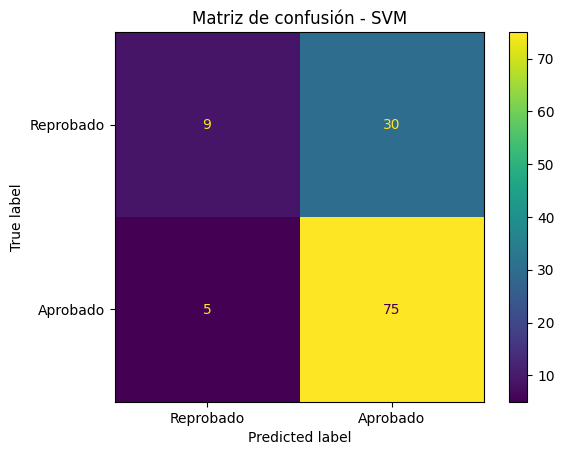

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_svm,
    display_labels=["Reprobado", "Aprobado"]
)

plt.title("Matriz de confusión - SVM")
plt.show()


In [ ]:
resultados_svm = pd.DataFrame({
    'real': y_test.values,
    'prediccion': pred_svm
}, index=y_test.index)

falsos_positivos_svm = resultados_svm[(resultados_svm['real'] == 0) & (resultados_svm['prediccion'] == 1)]
falsos_negativos_svm = resultados_svm[(resultados_svm['real'] == 1) & (resultados_svm['prediccion'] == 0)]

print(f"Falsos Positivos: {len(falsos_positivos_svm)}")
print(f"Falsos Negativos: {len(falsos_negativos_svm)}")

Falsos Positivos: 30
Falsos Negativos: 5


In [ ]:
df_copy.loc[falsos_positivos_svm.index].describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_bin
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.0
mean,0.900000,0.666667,17.266667,0.766667,0.700000,0.866667,2.766667,2.466667,1.400000,2.000000,...,2.900000,3.000000,1.500000,2.300000,3.433333,9.133333,8.066667,7.033333,5.733333,0.0
std,0.305129,0.479463,0.868345,0.430183,0.466092,0.345746,0.971431,1.008014,0.813676,0.742781,...,0.711967,0.909718,0.820008,1.316998,1.278019,12.161934,1.700575,2.399473,3.423381,0.0
min,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.0
25%,1.000000,0.000000,17.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,2.000000,...,3.000000,3.000000,1.000000,1.000000,3.000000,0.500000,7.000000,6.000000,5.250000,0.0
50%,1.000000,1.000000,17.000000,1.000000,1.000000,1.000000,3.000000,2.500000,1.000000,2.000000,...,3.000000,3.000000,1.000000,2.000000,3.000000,5.500000,8.000000,8.000000,6.500000,0.0
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,3.750000,3.000000,1.000000,2.000000,...,3.000000,3.750000,2.000000,3.000000,5.000000,11.500000,9.000000,8.750000,8.000000,0.0
max,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,5.000000,4.000000,5.000000,5.000000,56.000000,11.000000,10.000000,9.000000,0.0


In [ ]:
df_copy.loc[falsos_negativos_svm.index].describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_bin
count,5.0,5.000000,5.00000,5.000000,5.000000,5.0,5.000000,5.000000,5.000000,5.00000,...,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.0
mean,1.0,0.600000,16.40000,0.800000,0.800000,1.0,2.000000,1.600000,1.400000,2.20000,...,3.200000,2.60000,1.600000,2.800000,3.200000,5.600000,9.200000,9.60000,10.200000,1.0
std,0.0,0.547723,1.67332,0.447214,0.447214,0.0,0.707107,0.894427,0.547723,0.83666,...,1.095445,1.81659,0.547723,1.095445,0.447214,3.286335,1.643168,1.67332,0.447214,0.0
min,1.0,0.000000,15.00000,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.00000,...,2.000000,1.00000,1.000000,1.000000,3.000000,2.000000,7.000000,8.00000,10.000000,1.0
25%,1.0,0.000000,15.00000,1.000000,1.000000,1.0,2.000000,1.000000,1.000000,2.00000,...,3.000000,1.00000,1.000000,3.000000,3.000000,4.000000,8.000000,8.00000,10.000000,1.0
50%,1.0,1.000000,16.00000,1.000000,1.000000,1.0,2.000000,1.000000,1.000000,2.00000,...,3.000000,2.00000,2.000000,3.000000,3.000000,4.000000,10.000000,10.00000,10.000000,1.0
75%,1.0,1.000000,17.00000,1.000000,1.000000,1.0,2.000000,2.000000,2.000000,3.00000,...,3.000000,4.00000,2.000000,3.000000,3.000000,8.000000,10.000000,10.00000,10.000000,1.0
max,1.0,1.000000,19.00000,1.000000,1.000000,1.0,3.000000,3.000000,2.000000,3.00000,...,5.000000,5.00000,2.000000,4.000000,4.000000,10.000000,11.000000,12.00000,11.000000,1.0




---



---



---



### Comparación de los modelos

In [ ]:
resultados = pd.DataFrame([
    {
        "Modelo": "Regresión Logística",
        "Accuracy": accuracy_score(y_test, pred_log),
        "Precision": precision_score(y_test, pred_log),
        "Recall": recall_score(y_test, pred_log),
        "F1": f1_score(y_test, pred_log)
    },
    {
        "Modelo": "SVM",
        "Accuracy": accuracy_score(y_test, pred_svm),
        "Precision": precision_score(y_test, pred_svm),
        "Recall": recall_score(y_test, pred_svm),
        "F1": f1_score(y_test, pred_svm)
    }
])

resultados.round(4)


,Modelo,Accuracy,Precision,Recall,F1
0,Regresión Logística,0.6555,0.7191,0.8000,0.7574
1,SVM,0.7059,0.7143,0.9375,0.8108


In [ ]:
# Conteo y proporción
print(df_copy['G3_bin'].value_counts())
print(df_copy['G3_bin'].value_counts(normalize=True) * 100)



G3_bin
1    265
0    130
Name: count, dtype: int64
G3_bin
1    67.088608
0    32.911392
Name: proportion, dtype: float64


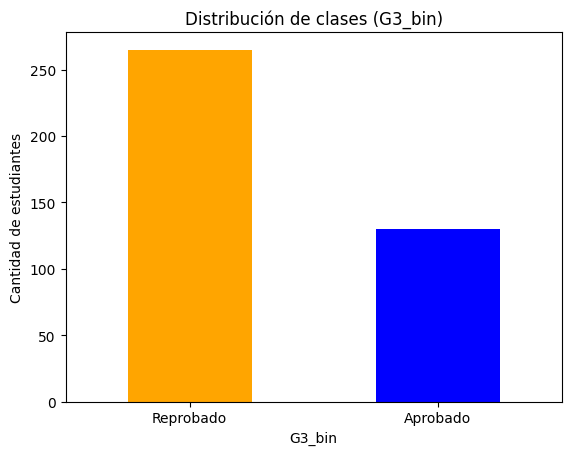

In [ ]:
# Visualización
df_copy['G3_bin'].value_counts().plot(kind='bar', color=['orange','blue'])
plt.xticks([0,1], ['Reprobado','Aprobado'], rotation=0)
plt.title('Distribución de clases (G3_bin)')
plt.ylabel('Cantidad de estudiantes')
plt.show()

In [ ]:
importancias = pd.DataFrame({
    'variable': modelo_logistico.named_steps['preprocesamiento'].get_feature_names_out(),
    'coeficiente': modelo_logistico.named_steps['modelo'].coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

print(importancias.head(10))

                variable  coeficiente
10         num__failures    -0.959711
21            num__goout    -0.735767
27      cat__Mjob_health     0.626890
30     cat__Mjob_teacher    -0.604525
23             num__Walc     0.597336
28       cat__Mjob_other    -0.576333
42   cat__guardian_other    -0.453966
29    cat__Mjob_services     0.413724
40  cat__guardian_father     0.350397
16           num__higher     0.349128


## Fase 3: Regresión - Regresión lineal

In [ ]:
df_Rl = df_copy.copy()
df_Rl.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_bin
0,1,1,18,1,1,0,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,0
1,1,1,17,1,1,1,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,0
2,1,1,15,1,0,1,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,1


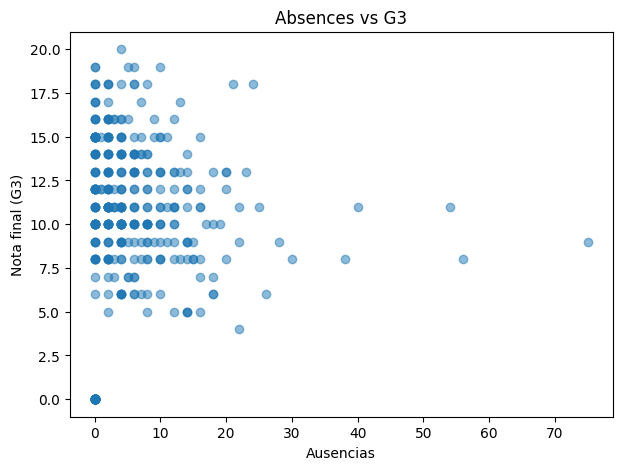

In [109]:
plt.figure(figsize=(7,5))
plt.scatter(df_Rl['absences'], df_Rl['G3'], alpha=0.5)
plt.xlabel('Ausencias')
plt.ylabel('Nota final (G3)')
plt.title('Absences vs G3')
plt.show()

In [ ]:
df_Rl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    int64 
 1   sex         395 non-null    int64 
 2   age         395 non-null    int64 
 3   address     395 non-null    int64 
 4   famsize     395 non-null    int64 
 5   Pstatus     395 non-null    int64 
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    int64 
 16  famsup      395 non-null    int64 
 17  paid        395 non-null    int64 
 18  activities  395 non-null    int64 
 19  nursery     395 non-null    int64 
 20  higher    

### Preparación

Como se demostró anteriormente no se utilizará G1 ni G2, pues la correlación entre las notas es bastante alta y podrían ser variables predictoras fuertes.



In [ ]:
from sklearn.linear_model import LinearRegression

col_binarias = ['school','sex','address','famsize','Pstatus','schoolsup',
                 'famsup','paid','activities','nursery','higher','internet','romantic']
col_nominales = ['Mjob','Fjob','reason','guardian']
col_numericas = ['age','Medu','Fedu','traveltime','studytime','failures',
                  'famrel','freetime','goout','Dalc','Walc','health','absences']

preprocesamiento_reg = ColumnTransformer(transformers=[
    ('bin', OneHotEncoder(drop='if_binary'), col_binarias),
    ('nom', OneHotEncoder(), col_nominales),
    ('num', StandardScaler(), col_numericas)
])

modelo_lineal = Pipeline(steps=[
    ('preprocesamiento', preprocesamiento_reg),
    ('modelo', LinearRegression())
])

In [ ]:
features =[
    'school', 'sex' , 'age', 'address', 'famsize',
           'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob',
     'reason', 'guardian', 'traveltime', 'studytime', 'failures',
     'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
    'higher', 'internet', 'romantic', 'famrel', 'freetime',
    'goout', 'Dalc', 'Walc', 'health', 'absences'
    ]

X_reg= df_Rl[features]
y_reg = df_Rl['G3']

print("X: ", X_reg.shape)
print("Y: ", y_reg.shape )

X:  (395, 30)
Y:  (395,)


In [ ]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=42
)

print("Entrenamiento:", X_reg_train.shape)
print("Prueba:", X_reg_test.shape)

Entrenamiento: (276, 30)
Prueba: (119, 30)


In [ ]:
modelo = LinearRegression()
modelo_lineal.fit(X_reg_train, y_reg_train)
predicciones = modelo_lineal.predict(X_reg_test)

print("Primeras predicciones:", np.round(predicciones[:5], 2))

Primeras predicciones: [ 2.58  7.96  8.3  11.53 10.79]


### Evaluación de regresión

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_reg_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_reg_test, predicciones))
r2 = r2_score(y_reg_test, predicciones)

print(f"MAE : {mae:.2f} promedio de error en la nota final")
print(f"RMSE: {rmse:.2f} promedio de error en la nota final")
print(f"R²  : {r2:.3f}")

MAE : 3.29 promedio de error en la nota final
RMSE: 4.22 promedio de error en la nota final
R²  : 0.191


## Comparación

In [ ]:
comparacion = pd.DataFrame({
    "Real": y_reg_test.values,
    "Predicho": predicciones
})
comparacion["Error_absoluto"] = abs(comparacion["Real"] - comparacion["Predicho"])
comparacion.head(10)

,Real,Predicho,Error_absoluto
0,10,2.581461,7.418539
1,12,7.964561,4.035439
2,5,8.303999,3.303999
3,10,11.534894,1.534894
4,9,10.794168,1.794168
5,13,10.081363,2.918637
6,18,12.822395,5.177605
7,6,12.485906,6.485906
8,0,10.774210,10.774210
9,14,12.722902,1.277098


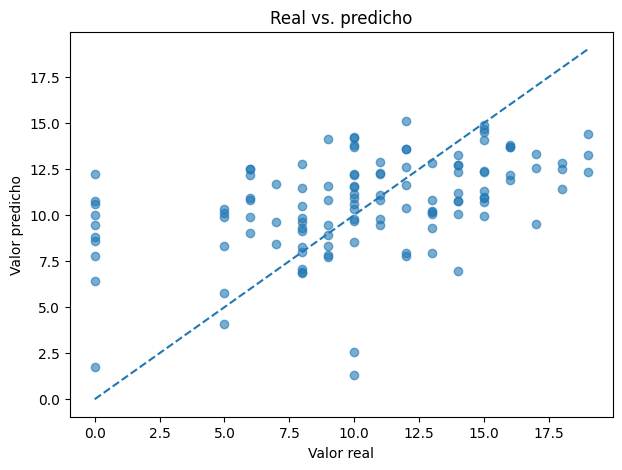

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_reg_test, predicciones, alpha=0.6)
a = min(y_reg_test.min(), predicciones.min())
b = max(y_reg_test.max(), predicciones.max())
plt.plot([a,b],[a,b], linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Real vs. predicho")
plt.show()

In [ ]:
comparacion.sort_values("Error_absoluto", ascending=False).head(10)

,Real,Predicho,Error_absoluto
109,0,12.201326,12.201326
8,0,10.774210,10.774210
24,0,10.574708,10.574708
86,0,10.008048,10.008048
94,0,9.447813,9.447813
57,0,8.831020,8.831020
62,10,1.334839,8.665161
19,0,8.607718,8.607718
89,0,7.753566,7.753566
65,17,9.490531,7.509469


## Fase 4: DevOps, MLOps y monitoreo

1. ¿Qué activiades correspondería a DevOps para gestionar el código, las pruebas, las versiones y un posible despliegue de la solución?

2. ¿Qué elementos adicionales debería gestionar MLOps relacionados con los datos, el modelo, sus versiones y sus métricas?

3. ¿Qué variables y métricas deberían monitorearse una vez que el modelo se encuentre funcionando?